# Drug Review Sentiment Classification — Model Results

Comparative analysis of three transformer models fine-tuned on the **Drugs.com review dataset**  
for 3-class drug review sentiment: **bad** / **medium** / **good**.

---

| Model | Base Architecture | Pre-training Domain | Params |
|-------|------------------|---------------------|--------|
| **Bio-ClinicalBERT** | BERT-base | Biomedical + clinical text | ~110M |
| **RoBERTa-Base** | RoBERTa-base | General web text | ~125M |
| **Sentiment-RoBERTa-Large** | RoBERTa-large | Sentiment-focused social text | ~355M |

**Training:** 3 epochs · lr = 2e-5 (encoder) / 2e-4 (head) · batch = 64 · max_len = 256  
**Dataset:** 115,149 balanced reviews · 80/20 split · 23,030 test samples (7,677 per class)

In [7]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

MODEL_DIRS = {
    "Bio-ClinicalBERT":        "Bio_ClinicalBERT",
    "RoBERTa-Base":            "roberta-base",
    "Sentiment-RoBERTa-Large": "sentiment-roberta-large-english",
}
COLORS = {
    "Bio-ClinicalBERT":        "#4C72B0",
    "RoBERTa-Base":            "#E07B39",
    "Sentiment-RoBERTa-Large": "#2E9E5B",
}
MARKERS = {
    "Bio-ClinicalBERT":        "o",
    "RoBERTa-Base":            "s",
    "Sentiment-RoBERTa-Large": "^",
}
CLASSES = ["bad", "medium", "good"]
BASE_DIR = Path(".")

In [8]:
# Load epoch metrics and per-step batch losses
epoch_dfs = {}
batch_dfs = {}
for label, folder in MODEL_DIRS.items():
    epoch_dfs[label] = pd.read_csv(BASE_DIR / folder / "epoch_metrics.csv")
    batch_dfs[label] = pd.read_csv(BASE_DIR / folder / "batch_losses.csv")

# Classification report values (from test set classification_report.txt)
clf_report = {
    "Bio-ClinicalBERT": {
        "bad":    {"Precision": 0.83, "Recall": 0.82, "F1": 0.82},
        "medium": {"Precision": 0.68, "Recall": 0.74, "F1": 0.71},
        "good":   {"Precision": 0.87, "Recall": 0.81, "F1": 0.84},
        "Accuracy": 0.79, "Macro F1": 0.79,
    },
    "RoBERTa-Base": {
        "bad":    {"Precision": 0.83, "Recall": 0.85, "F1": 0.84},
        "medium": {"Precision": 0.72, "Recall": 0.72, "F1": 0.72},
        "good":   {"Precision": 0.87, "Recall": 0.85, "F1": 0.86},
        "Accuracy": 0.81, "Macro F1": 0.81,
    },
    "Sentiment-RoBERTa-Large": {
        "bad":    {"Precision": 0.87, "Recall": 0.84, "F1": 0.86},
        "medium": {"Precision": 0.73, "Recall": 0.77, "F1": 0.75},
        "good":   {"Precision": 0.88, "Recall": 0.86, "F1": 0.87},
        "Accuracy": 0.82, "Macro F1": 0.83,
    },
}
models = list(clf_report.keys())

print("Data loaded successfully")
for label, df in epoch_dfs.items():
    print(f"  {label}: {len(df)} epochs | {len(batch_dfs[label]):,} training steps")

Data loaded successfully
  Bio-ClinicalBERT: 3 epochs | 4,320 training steps
  RoBERTa-Base: 3 epochs | 4,320 training steps
  Sentiment-RoBERTa-Large: 3 epochs | 4,320 training steps


---
## 1. Training Loss Trajectory (Batch Level)

Raw per-step loss is noisy; the bold curve shows a 100-step rolling average.  
Dashed vertical lines mark epoch boundaries (every 1,440 steps).

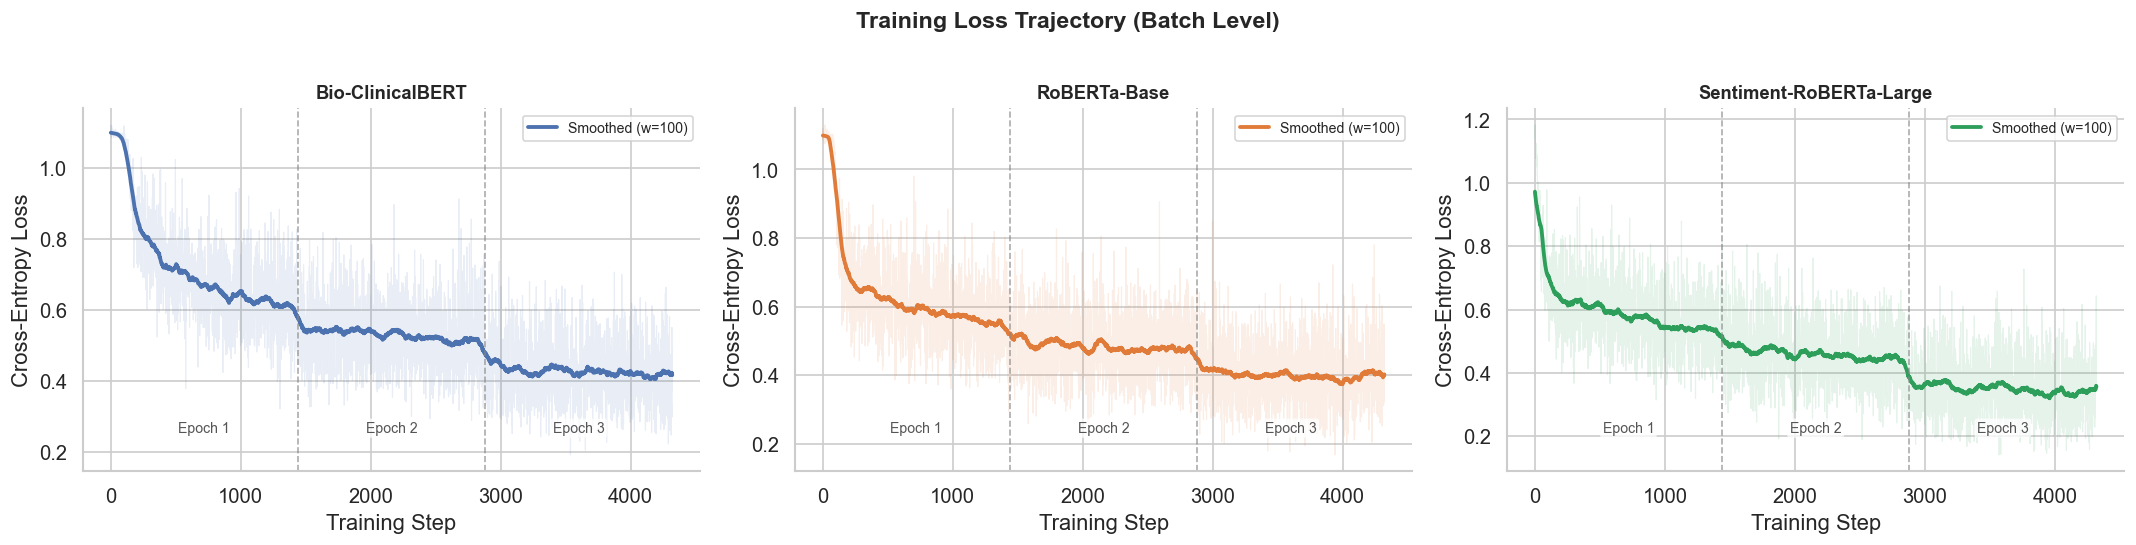

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=False)
fig.suptitle("Training Loss Trajectory (Batch Level)", fontsize=14, fontweight="bold", y=1.01)

for ax, (label, df) in zip(axes, batch_dfs.items()):
    color  = COLORS[label]
    steps  = df["step"].values
    losses = df["loss"].values.astype(float)
    smoothed = pd.Series(losses).rolling(window=100, center=True, min_periods=1).mean().values

    ax.plot(steps, losses,   color=color, alpha=0.12, linewidth=0.7)
    ax.plot(steps, smoothed, color=color, linewidth=2.3, label="Smoothed (w=100)")

    # Epoch boundary lines
    epoch_ends = epoch_dfs[label]["end_step"].values
    for end in epoch_ends[:-1]:
        ax.axvline(end, color="#888888", linestyle="--", linewidth=1.0, alpha=0.7)

    # Epoch mid-point labels
    boundaries = [0] + list(epoch_ends)
    ymin, ymax = losses.min(), losses.max()
    for i in range(3):
        mid = (boundaries[i] + boundaries[i + 1]) / 2
        ax.text(mid, ymin + (ymax - ymin) * 0.06, f"Epoch {i + 1}",
                ha="center", va="bottom", fontsize=8.5, color="#555555",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", alpha=0.75, ec="none"))

    ax.legend(fontsize=8.5, loc="upper right")
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Cross-Entropy Loss")

plt.tight_layout()
plt.savefig("fig1_batch_loss.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 2. Epoch-Level Training Dynamics

Training and validation **loss** (top row) and **F1 score** (bottom row) at the end of each epoch.  
Shaded bands highlight the train–val gap; a widening gap signals overfitting.

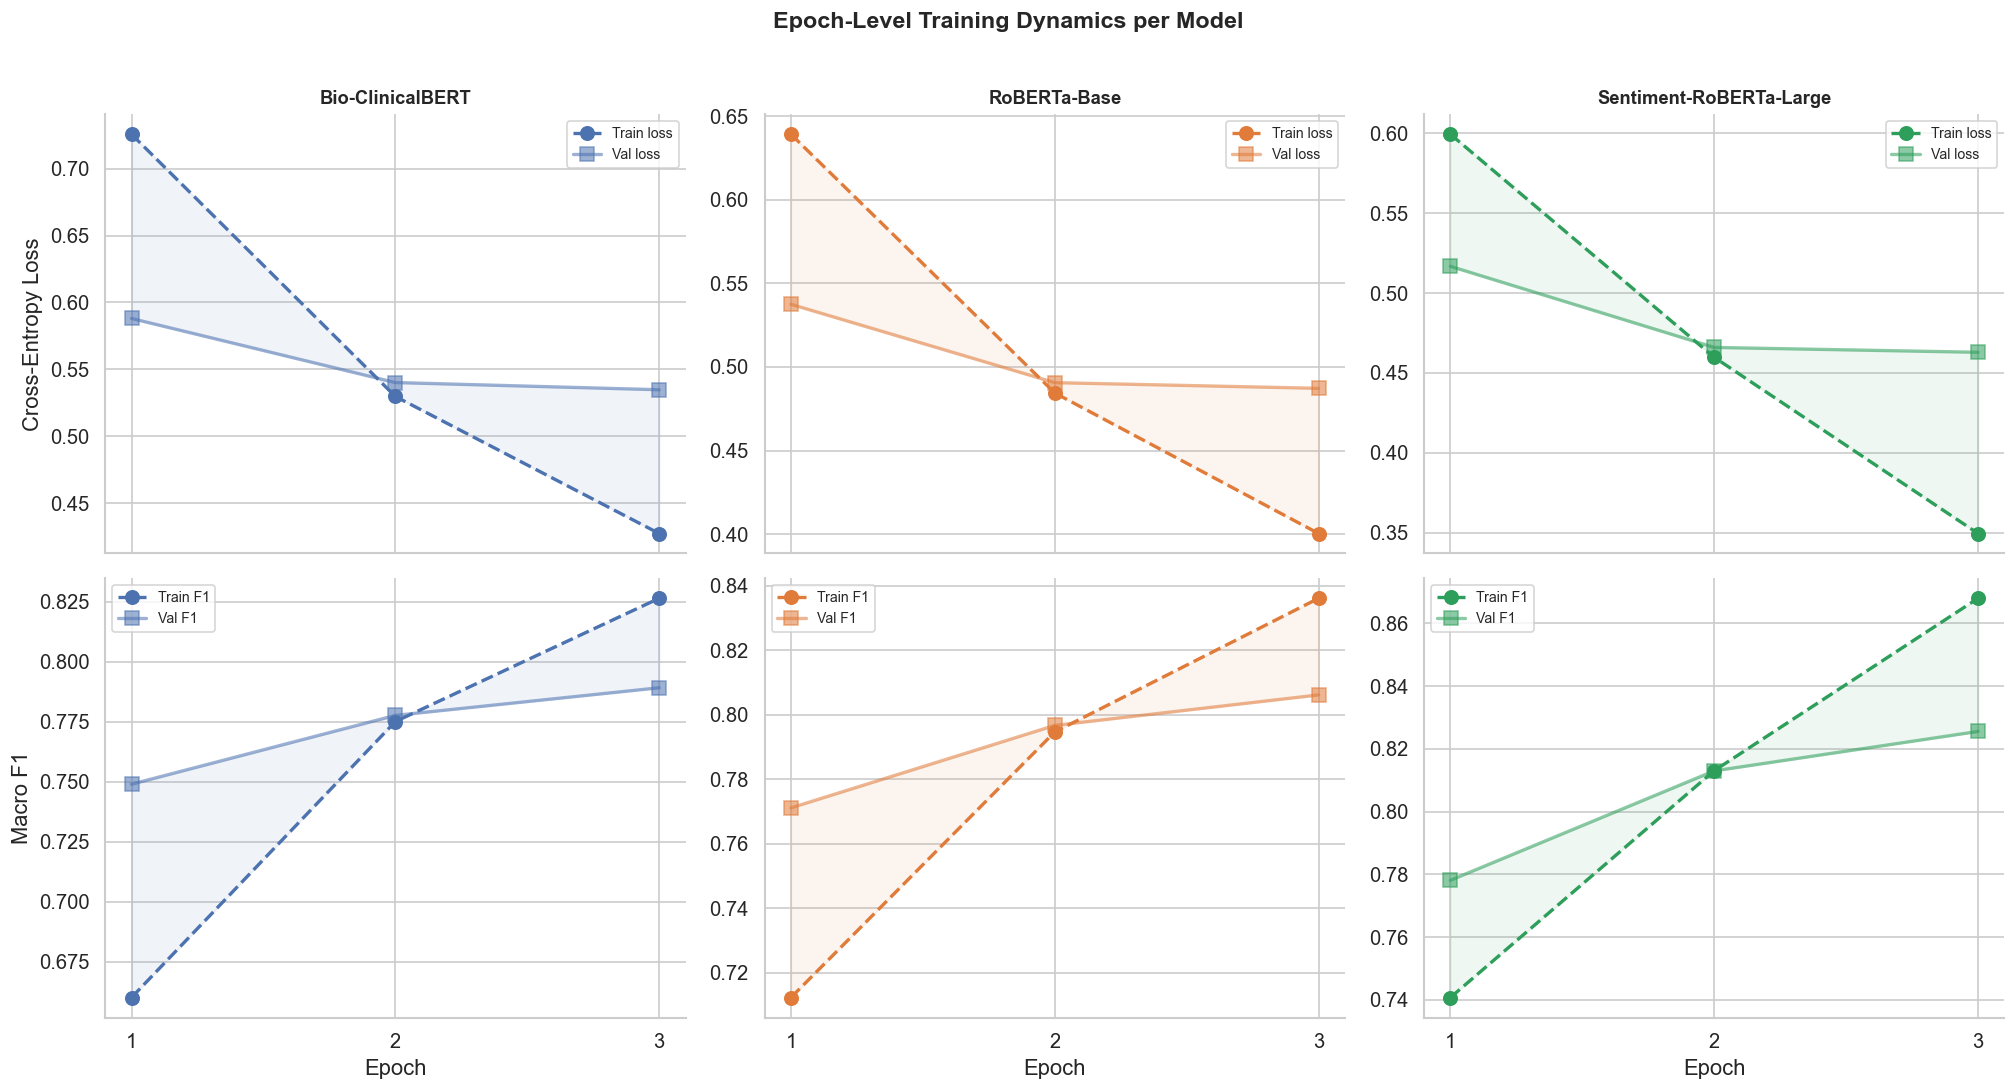

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
fig.suptitle("Epoch-Level Training Dynamics per Model", fontsize=14, fontweight="bold", y=1.01)

for col, (label, df) in enumerate(epoch_dfs.items()):
    color = COLORS[label]

    # Loss — row 0
    ax_l = axes[0, col]
    ax_l.plot(df["epoch"], df["train_loss"], "o--",
              color=color, linewidth=2, markersize=8, label="Train loss")
    ax_l.plot(df["epoch"], df["val_loss"],   "s-",
              color=color, linewidth=2, markersize=8, alpha=0.55, label="Val loss")
    ax_l.fill_between(df["epoch"], df["train_loss"], df["val_loss"],
                      color=color, alpha=0.08)
    ax_l.set_title(label, fontweight="bold", fontsize=11)
    ax_l.set_ylabel("Cross-Entropy Loss" if col == 0 else "")
    ax_l.legend(fontsize=8.5)
    ax_l.set_xticks([1, 2, 3])

    # F1 — row 1
    ax_f = axes[1, col]
    ax_f.plot(df["epoch"], df["train_f1"], "o--",
              color=color, linewidth=2, markersize=8, label="Train F1")
    ax_f.plot(df["epoch"], df["val_f1"],   "s-",
              color=color, linewidth=2, markersize=8, alpha=0.55, label="Val F1")
    ax_f.fill_between(df["epoch"], df["train_f1"], df["val_f1"],
                      color=color, alpha=0.08)
    ax_f.set_ylabel("Macro F1" if col == 0 else "")
    ax_f.set_xlabel("Epoch")
    ax_f.legend(fontsize=8.5)
    ax_f.set_xticks([1, 2, 3])

plt.tight_layout()
plt.savefig("fig2_epoch_dynamics.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 3. Cross-Model Validation Comparison

All three models overlaid — easier to see which learns faster and converges to a better plateau.

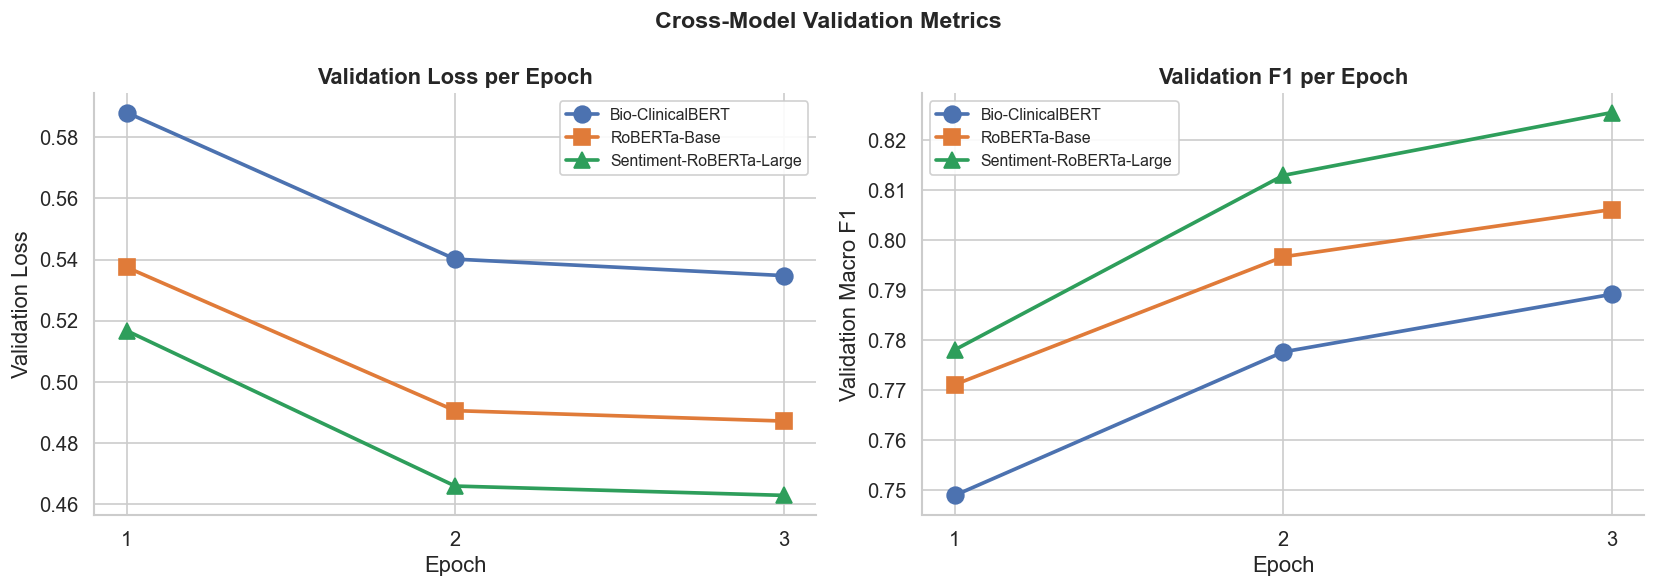

In [11]:
fig, (ax_loss, ax_f1) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Model Validation Metrics", fontsize=14, fontweight="bold")

for label, df in epoch_dfs.items():
    c = COLORS[label]
    m = MARKERS[label]
    kw = dict(color=c, linewidth=2.2, markersize=10, label=label)
    ax_loss.plot(df["epoch"], df["val_loss"], m + "-", **kw)
    ax_f1.plot(df["epoch"],  df["val_f1"],  m + "-", **kw)

for ax, ylabel, title in [
    (ax_loss, "Validation Loss",     "Validation Loss per Epoch"),
    (ax_f1,   "Validation Macro F1", "Validation F1 per Epoch"),
]:
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([1, 2, 3])
    ax.legend(fontsize=9.5, framealpha=0.9)

plt.tight_layout()
plt.savefig("fig3_cross_model_val.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 4. Test Set Overall Performance

Evaluation on the held-out test set (23,030 samples, perfectly balanced classes).  
Solid bars = **accuracy**, hatched bars = **macro F1** — for balanced classes these should be close.

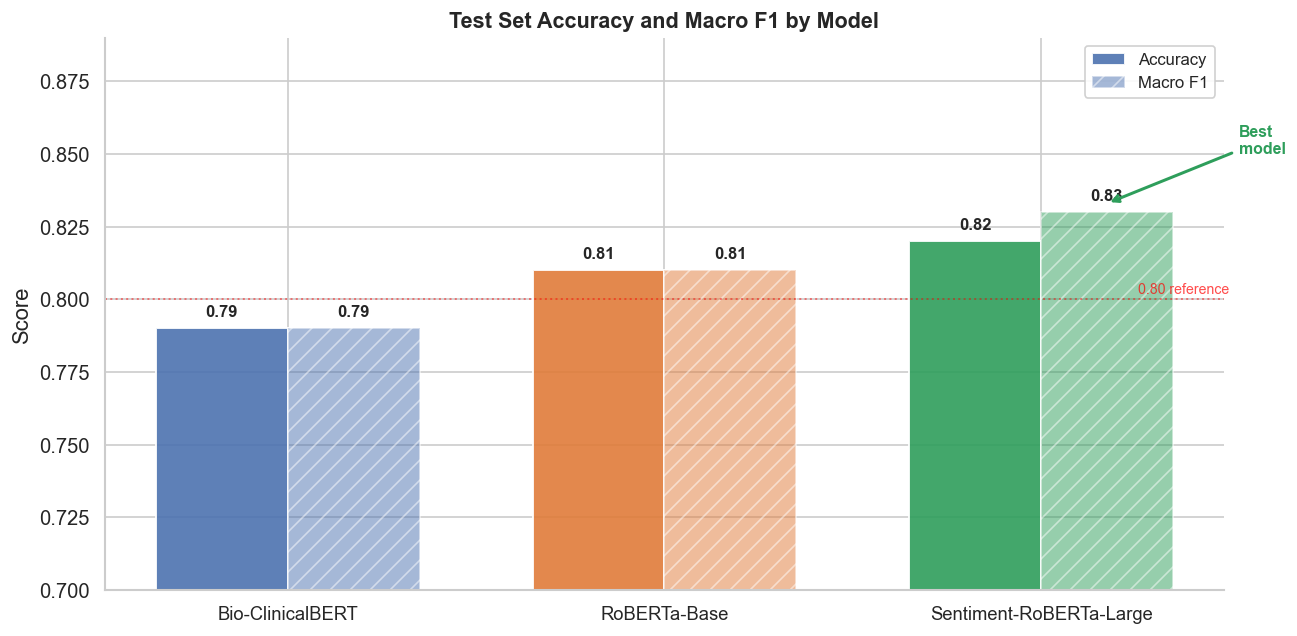

In [12]:
accuracy = [clf_report[m]["Accuracy"]  for m in models]
macro_f1 = [clf_report[m]["Macro F1"] for m in models]
x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
bars1 = ax.bar(x - w / 2, accuracy, w, label="Accuracy",
               color=[COLORS[m] for m in models], alpha=0.90,
               edgecolor="white", linewidth=1.2)
bars2 = ax.bar(x + w / 2, macro_f1, w, label="Macro F1",
               color=[COLORS[m] for m in models], alpha=0.50,
               edgecolor="white", linewidth=1.2, hatch="//")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
            f"{h:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.70, 0.89)
ax.set_ylabel("Score")
ax.set_title("Test Set Accuracy and Macro F1 by Model", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, framealpha=0.9)
ax.axhline(0.80, color="red", linestyle=":", linewidth=1.2, alpha=0.45)
ax.text(2.5, 0.802, "0.80 reference", fontsize=8.5, color="red", alpha=0.7, ha="right")

# Best model arrow
best_idx = int(np.argmax(macro_f1))
ax.annotate("Best\nmodel",
            xy=(x[best_idx] + w / 2, macro_f1[best_idx] + 0.003),
            xytext=(x[best_idx] + w / 2 + 0.35, macro_f1[best_idx] + 0.020),
            arrowprops=dict(arrowstyle="->", color="#2E9E5B", lw=1.8),
            fontsize=9.5, color="#2E9E5B", fontweight="bold")

plt.tight_layout()
plt.savefig("fig4_overall_performance.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 5. Per-Class Performance Analysis

The **medium** class covers ambiguous reviews (ratings 4–7) that sit at the boundary of positive and negative sentiment.  
Precision, Recall and F1 are broken down per class to reveal where each model struggles.

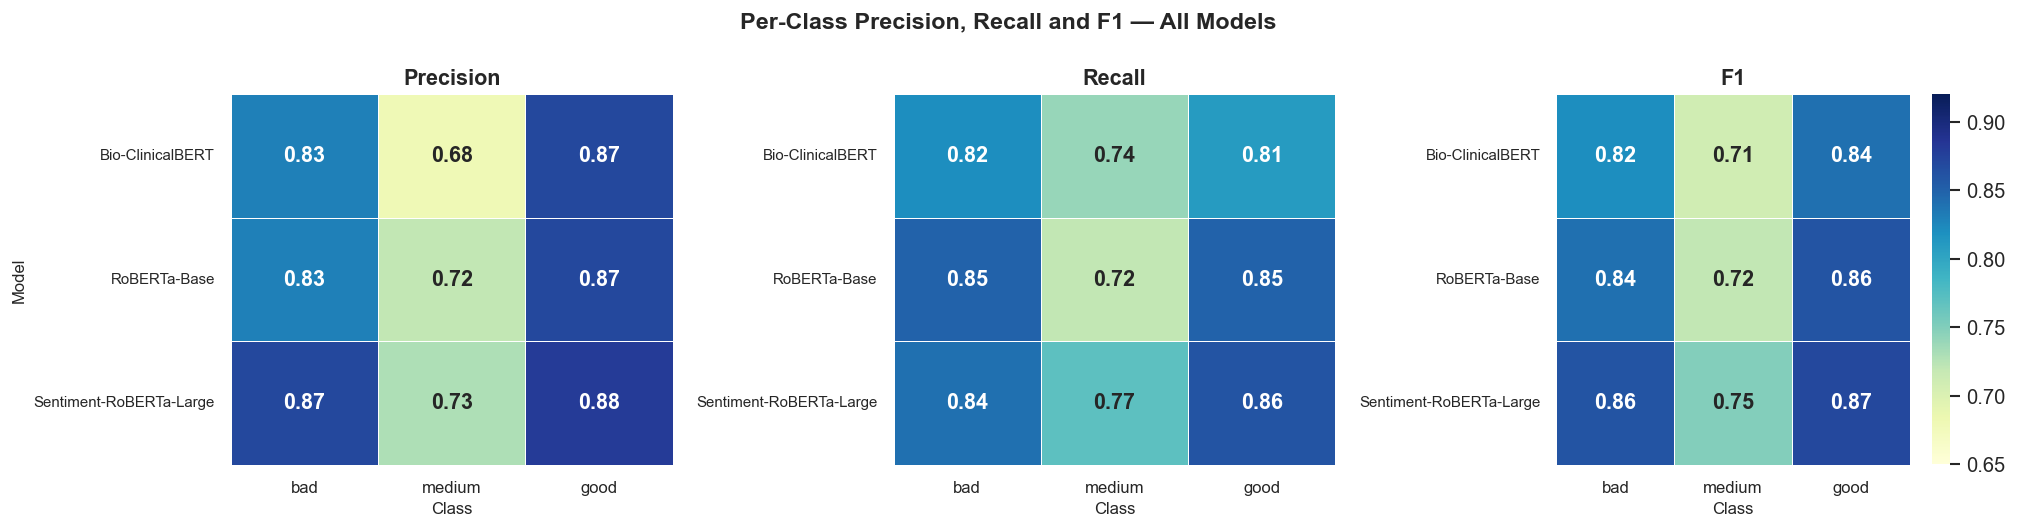

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle("Per-Class Precision, Recall and F1 — All Models", fontsize=14, fontweight="bold")

for ax, metric in zip(axes, ["Precision", "Recall", "F1"]):
    mat = pd.DataFrame(
        {cls: [clf_report[m][cls][metric] for m in models] for cls in CLASSES},
        index=models,
    )
    sns.heatmap(
        mat, annot=True, fmt=".2f", cmap="YlGnBu",
        vmin=0.65, vmax=0.92, linewidths=0.6, linecolor="white",
        annot_kws={"size": 13, "weight": "bold"},
        ax=ax, cbar=(metric == "F1"),
    )
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xlabel("Class", fontsize=10)
    ax.set_ylabel("Model" if metric == "Precision" else "", fontsize=10)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig("fig5_heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

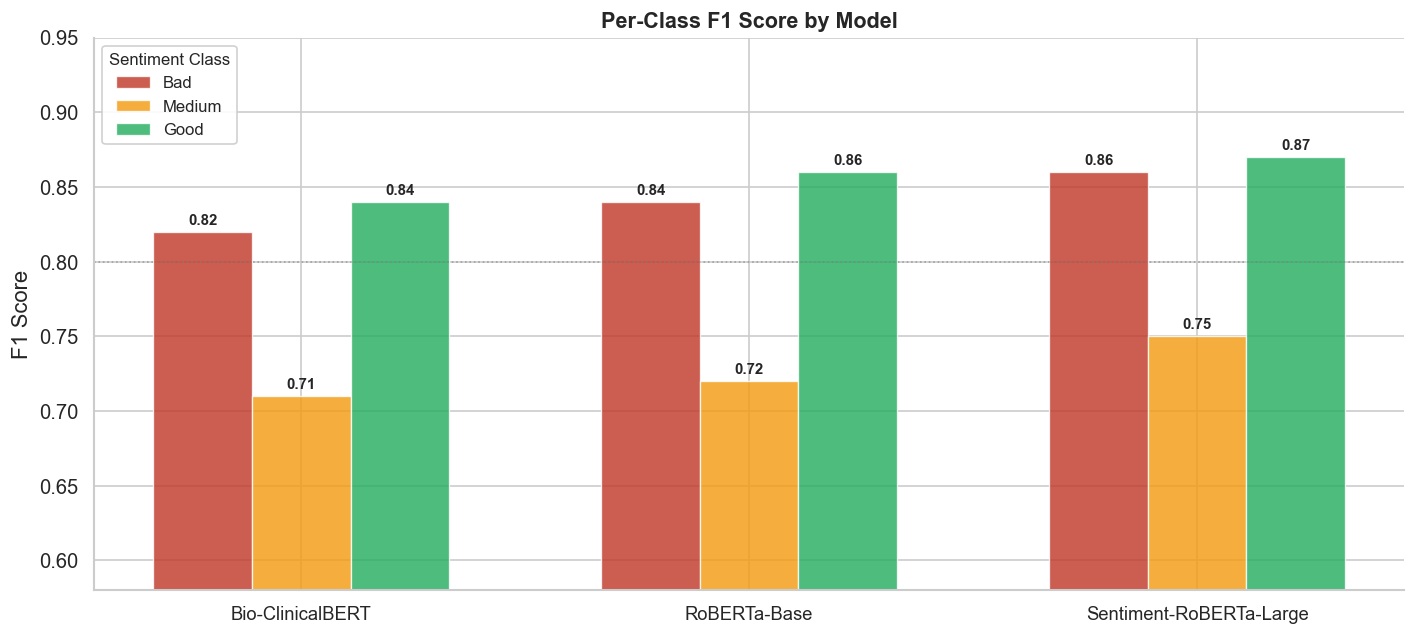

In [14]:
# Grouped bar: x-axis = model, groups = class, y = F1
class_colors = {"bad": "#C0392B", "medium": "#F39C12", "good": "#27AE60"}
n_classes = len(CLASSES)
bar_width = 0.22
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(12, 5.5))

for i, cls in enumerate(CLASSES):
    offset = (i - (n_classes - 1) / 2) * bar_width
    f1_vals = [clf_report[m][cls]["F1"] for m in models]
    bars = ax.bar(x + offset, f1_vals, bar_width,
                  label=cls.capitalize(),
                  color=class_colors[cls], alpha=0.82,
                  edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.58, 0.95)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score by Model", fontsize=13, fontweight="bold")
ax.legend(title="Sentiment Class", fontsize=10, title_fontsize=10, framealpha=0.9)
ax.axhline(0.80, color="gray", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()
plt.savefig("fig6_perclass_f1.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 6. Generalisation Analysis

The gap between training and validation F1 quantifies overfitting.  
A growing gap across epochs means the model is memorising training data rather than generalising.

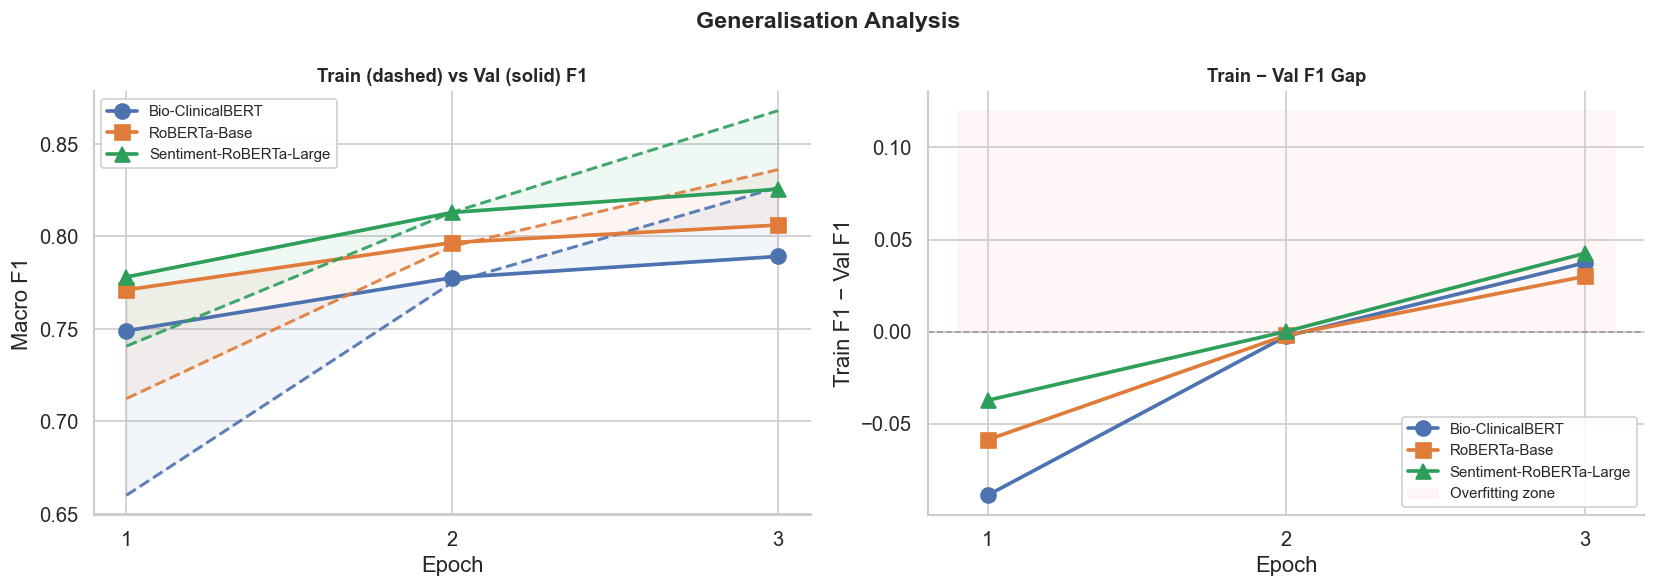

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Generalisation Analysis", fontsize=14, fontweight="bold")

# Left: Train vs Val F1 overlay
ax_left = axes[0]
for label, df in epoch_dfs.items():
    c = COLORS[label]
    ax_left.plot(df["epoch"], df["train_f1"], "--", color=c, lw=1.8, alpha=0.9)
    ax_left.plot(df["epoch"], df["val_f1"],   "-",  color=c, lw=2.2,
                 marker=MARKERS[label], ms=9, label=label)
    ax_left.fill_between(df["epoch"], df["train_f1"], df["val_f1"], color=c, alpha=0.07)

ax_left.set_title("Train (dashed) vs Val (solid) F1", fontsize=11, fontweight="bold")
ax_left.set_xlabel("Epoch")
ax_left.set_ylabel("Macro F1")
ax_left.set_xticks([1, 2, 3])
ax_left.legend(fontsize=9, framealpha=0.9)

# Right: Train-Val gap per epoch
ax_right = axes[1]
for label, df in epoch_dfs.items():
    gap = (df["train_f1"] - df["val_f1"]).values
    ax_right.plot(df["epoch"], gap, MARKERS[label] + "-",
                  color=COLORS[label], lw=2.2, ms=9, label=label)

ax_right.axhline(0, color="gray", linestyle="--", lw=1.0, alpha=0.7)
ax_right.fill_between([0.9, 3.1], 0, 0.12, color="#FFCCCC", alpha=0.15, label="Overfitting zone")
ax_right.set_title("Train − Val F1 Gap", fontsize=11, fontweight="bold")
ax_right.set_xlabel("Epoch")
ax_right.set_ylabel("Train F1 \u2212 Val F1")
ax_right.set_xticks([1, 2, 3])
ax_right.set_xlim(0.8, 3.2)
ax_right.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("fig7_generalisation.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 7. Learning Rate Sensitivity — Training Loss vs Validation F1 Trade-off

A scatter plot of the final training loss vs. the best validation F1 achieved.  
Lower loss and higher F1 = top-right quadrant = best model.

C:\Users\azouh\AppData\Local\Temp\ipykernel_12936\2876490495.py:27: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\azouh\AppData\Local\Temp\ipykernel_12936\2876490495.py:28: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig("fig_scatter_tradeoff.png", bbox_inches="tight", dpi=150)
c:\Users\azouh\Documents\EBM\4t\2sem\IA\porject_IA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


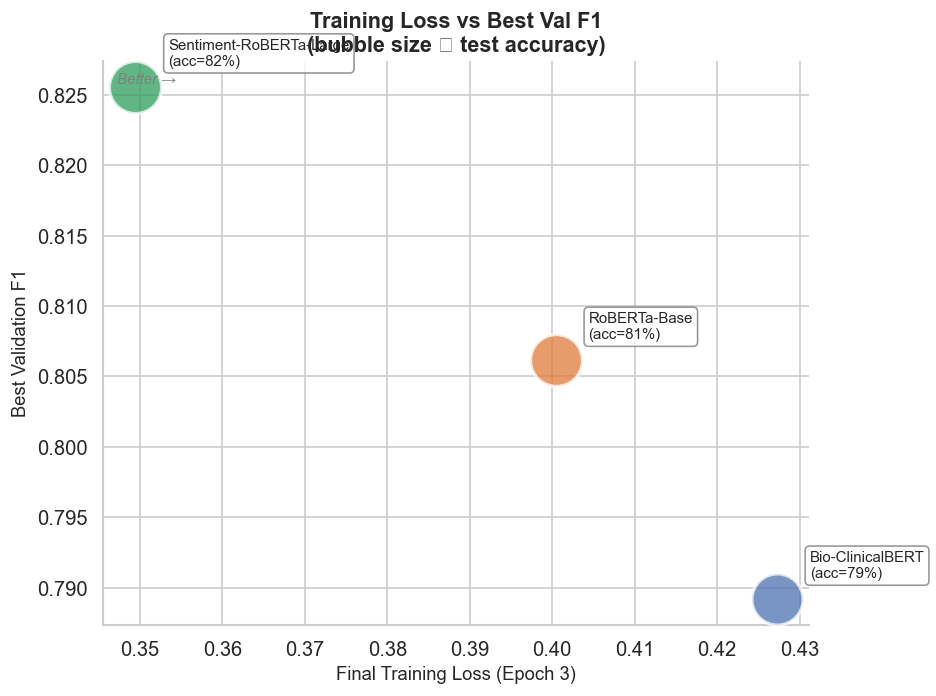

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, df in epoch_dfs.items():
    final_train_loss = df["train_loss"].iloc[-1]
    best_val_f1      = df["val_f1"].max()
    test_acc         = clf_report[label]["Accuracy"]

    # Bubble size proportional to test accuracy
    ax.scatter(final_train_loss, best_val_f1,
               s=test_acc * 1200, color=COLORS[label], alpha=0.75,
               edgecolors="white", linewidth=2, zorder=3, label=label)
    ax.annotate(
        f"{label}\n(acc={test_acc:.0%})",
        xy=(final_train_loss, best_val_f1),
        xytext=(final_train_loss + 0.004, best_val_f1 + 0.0015),
        fontsize=9, ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="gray"),
    )

ax.set_xlabel("Final Training Loss (Epoch 3)", fontsize=11)
ax.set_ylabel("Best Validation F1", fontsize=11)
ax.set_title("Training Loss vs Best Val F1\n(bubble size ∝ test accuracy)",
             fontsize=13, fontweight="bold")
ax.text(0.02, 0.98, "Better →", transform=ax.transAxes,
        ha="left", va="top", fontsize=9, color="gray", style="italic")

plt.tight_layout()
plt.savefig("fig_scatter_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 8. Summary Radar Chart

An at-a-glance multi-dimensional view of each model's strengths across five key metrics.

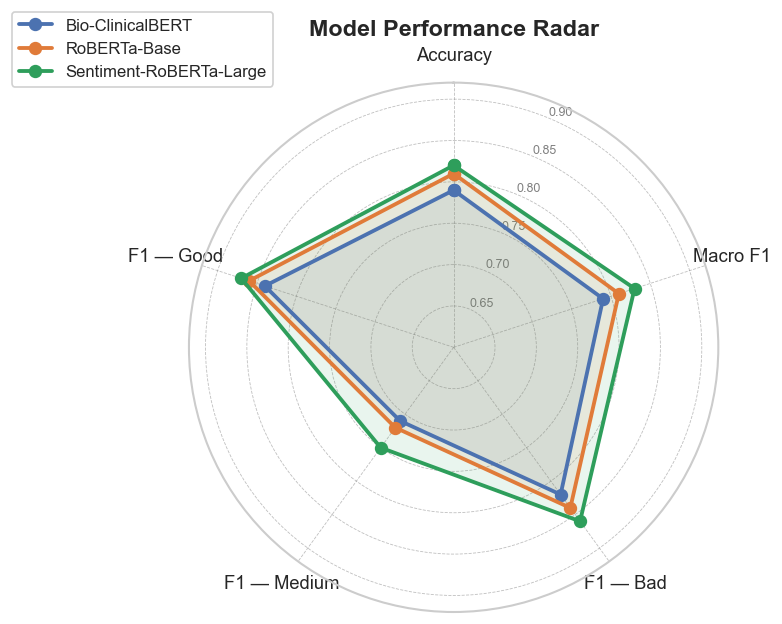

In [17]:
categories = ["Accuracy", "Macro F1", "F1 — Bad", "F1 — Medium", "F1 — Good"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0.60, 0.92)
ax.set_yticks([0.65, 0.70, 0.75, 0.80, 0.85, 0.90])
ax.set_yticklabels(["0.65", "0.70", "0.75", "0.80", "0.85", "0.90"],
                   fontsize=7.5, color="gray")
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

for label, data in clf_report.items():
    values = [
        data["Accuracy"],
        data["Macro F1"],
        data["bad"]["F1"],
        data["medium"]["F1"],
        data["good"]["F1"],
    ]
    values += values[:1]
    ax.plot(angles, values, "o-",
            linewidth=2.3, color=COLORS[label], label=label, markersize=7)
    ax.fill(angles, values, alpha=0.10, color=COLORS[label])

ax.legend(loc="upper left", bbox_to_anchor=(-0.35, 1.15), fontsize=10, framealpha=0.9)
ax.set_title("Model Performance Radar", fontsize=14, fontweight="bold", pad=28)

plt.tight_layout()
plt.savefig("fig8_radar.png", bbox_inches="tight", dpi=150)
plt.show()

---
## 9. Summary Table

In [18]:
rows = []
for m in models:
    d = clf_report[m]
    rows.append({
        "Model":           m,
        "Test Accuracy":   d["Accuracy"],
        "Macro F1":        d["Macro F1"],
        "Bad F1":          d["bad"]["F1"],
        "Medium F1":       d["medium"]["F1"],
        "Good F1":         d["good"]["F1"],
        "Best Val F1":     round(epoch_dfs[m]["val_f1"].max(), 4),
        "Final Train F1":  round(epoch_dfs[m]["train_f1"].iloc[-1], 4),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

styled = (
    summary_df.style
    .set_caption("Test Set Performance Summary")
    .format("{:.3f}")
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 1.2em; font-weight: bold; padding-bottom: 8px;"},
        {"selector": "th",
         "props": "background-color: #2C3E50; color: white; padding: 9px 14px; font-size: 11px;"},
        {"selector": "td",
         "props": "padding: 8px 14px; text-align: center; font-size: 11px;"},
        {"selector": "tr:nth-child(even)",
         "props": "background-color: #F2F2F2;"},
    ])
    .highlight_max(axis=0, color="#ABEBC6")
    .highlight_min(axis=0, color="#FADBD8")
)
display(styled)

,Test Accuracy,Macro F1,Bad F1,Medium F1,Good F1,Best Val F1,Final Train F1
Model,,,,,,,
Bio-ClinicalBERT,0.790,0.790,0.820,0.710,0.840,0.789,0.827
RoBERTa-Base,0.810,0.810,0.840,0.720,0.860,0.806,0.836
Sentiment-RoBERTa-Large,0.820,0.830,0.860,0.750,0.870,0.826,0.868


---
## Key Takeaways

### Model Ranking
1. **Sentiment-RoBERTa-Large** — Best overall (82% accuracy, 0.83 macro F1).  
   Sentiment-focused pre-training aligns directly with the task; larger capacity (~355M params) also contributes.
2. **RoBERTa-Base** — Strong runner-up (81% / 0.81).  
   Robustly optimised pre-training beats domain adaptation on this opinion-heavy dataset.
3. **Bio-ClinicalBERT** — Weakest overall (79% / 0.79).  
   Clinical text is factual, not opinion-driven — the domain transfer is a mismatch for consumer sentiment.

### Class Difficulty
| Class | Typical F1 range | Why |
|-------|-----------------|-----|
| **Medium** | 0.71 – 0.75 | Ambiguous reviews at the boundary of bad/good sentiment |
| **Bad** | 0.82 – 0.86 | Strong negative language is distinctive |
| **Good** | 0.84 – 0.87 | Strong positive language is most frequent and distinctive |

### Generalisation
All models show a mild train–val F1 gap that widens with epochs, but converging val losses suggest  
training has not fully saturated. Additional epochs could help with 92K training samples.

### Recommendation
- **For best performance:** `sentiment-roberta-large-english` — highest accuracy and F1 across all classes.
- **For cost-efficiency:** `roberta-base` — only ~2% lower macro F1 with 3× fewer parameters.
- **Avoid for this task:** `Bio_ClinicalBERT` — medical domain pre-training does not benefit consumer sentiment.